# European day-ahead markets: data, battery value and forecasts

A walkthrough of the project on **real ENTSO-E data**: six bidding zones, 1 January 2024 to
31 December 2025 (731 delivery days per zone).

The notebook contains no logic of its own. Every number comes from functions in
`src/eupm/`, which are covered by the test suite. The notebook calls those functions and
explains the results. The sections follow the pipeline:

1. **The data**: what one week of a market looks like
2. **Quality first**: checks run before any analysis
3. **Arbitrage atlas**: where a battery earns most, and why
4. **Market coupling**: which zones move together
5. **Forecasting**: scored on battery revenue, not only on error
6. **Explaining a forecast**: what drove one evening's price
7. **Limits and next steps**

To re-run it: `uv run eupm backtest --zones PL NL DE_LU BE FR ES` (needs `ENTSOE_API_KEY`),
then run this notebook top to bottom.

In [1]:
from datetime import date, timedelta
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import polars as pl

from eupm.analytics import eu_feature_columns, eu_features
from eupm.config import ModelConfig
from eupm.data.entsoe import EntsoeConfig, load_or_fetch_zone
from eupm.models import LightGBMQuantile

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
REPORTS = ROOT / "reports"
TZ = "Europe/Brussels"  # SDAC delivery days run 00:00-24:00 CET/CEST
ZONES = ["PL", "NL", "DE_LU", "BE", "FR", "ES"]

# Reads the Parquet cache written by `eupm fetch`; only calls the API if a file is missing.
cfg = EntsoeConfig(
    zones=ZONES, start=date(2024, 1, 1), end=date(2025, 12, 31), cache_dir=ROOT / "data/entsoe"
)
frames = {z: load_or_fetch_zone(z, cfg) for z in ZONES}

# One fixed colour per zone, used in every chart.
COLOR = dict(zip(ZONES, ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300"]))
plt.rcParams.update({
    "figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "axes.axisbelow": True, "grid.color": "#e4e3df", "grid.linewidth": 0.6,
    "axes.edgecolor": "#8a8984", "axes.labelcolor": "#52514e",
    "xtick.color": "#52514e", "ytick.color": "#52514e", "lines.linewidth": 2,
    "font.size": 10, "axes.titlesize": 11, "axes.titleweight": "bold", "axes.titlelocation": "left",
})
pl.Config(tbl_rows=20, tbl_cols=-1, float_precision=1, tbl_width_chars=160)
frames["DE_LU"].head()

start_time,price,load_fc,solar_fc,wind_fc,residual_load_fc
"datetime[μs, UTC]",f64,f64,f64,f64,f64
2023-12-31 23:00:00 UTC,0.2,39981.7,0.0,35376.7,4605.0
2024-01-01 00:00:00 UTC,0.0,38085.8,0.0,34897.8,3188.0
2024-01-01 01:00:00 UTC,-0.1,37063.5,0.0,34576.9,2486.6
2024-01-01 02:00:00 UTC,-1.0,36834.4,0.0,34137.9,2696.5
2024-01-01 03:00:00 UTC,-1.8,36835.2,0.0,33765.1,3070.2


## 1. The data

Each zone is one hourly table: the day-ahead price, plus the **day-ahead forecasts** of load,
solar and wind that ENTSO-E publishes before the auction. Residual load (load − solar − wind)
is the demand left for dispatchable plants, and is the main fundamental driver of price.

Below is the week in Germany with the lowest price in the sample. Prices fall below zero when
solar and wind cover almost all of the load at midday.

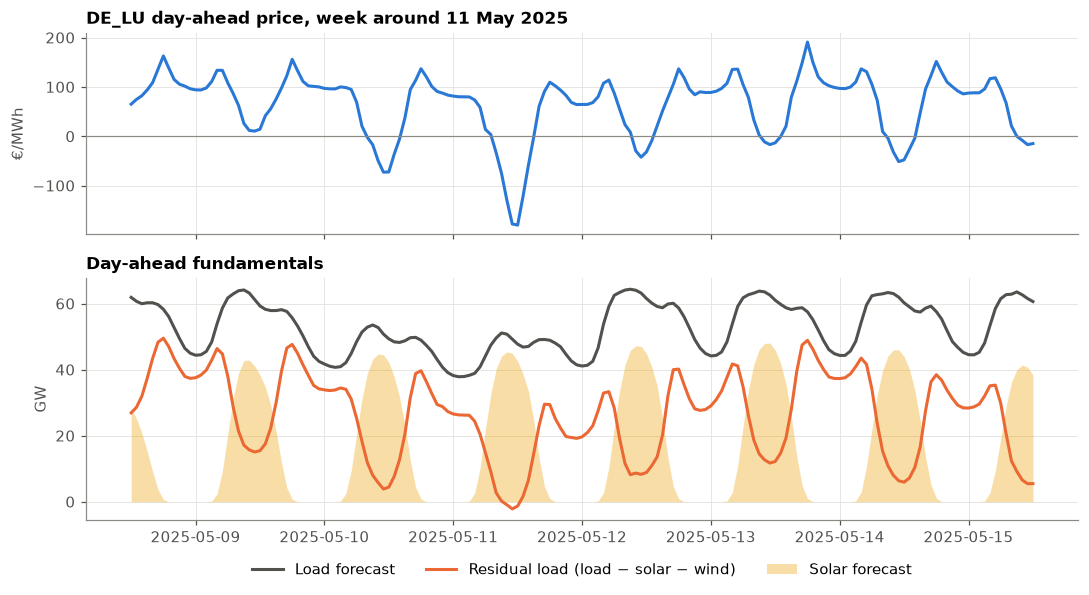

In [2]:
de = frames["DE_LU"].with_columns(pl.col("start_time").dt.convert_time_zone(TZ).alias("t"))
low = de.sort("price")["t"][0]
week = de.filter(pl.col("t").is_between(low - timedelta(days=3), low + timedelta(days=4)))

fig, (a1, a2) = plt.subplots(2, 1, figsize=(10, 5.5), sharex=True, height_ratios=[1, 1.2])
a1.plot(week["t"], week["price"], color="#2a78d6")
a1.axhline(0, color="#8a8984", linewidth=0.8)
a1.set_ylabel("€/MWh")
a1.set_title(f"DE_LU day-ahead price, week around {low:%d %b %Y}")
a2.plot(week["t"], week["load_fc"] / 1e3, color="#52514e", label="Load forecast")
a2.plot(week["t"], week["residual_load_fc"] / 1e3, color="#eb6834", label="Residual load (load − solar − wind)")
a2.fill_between(week["t"], 0, week["solar_fc"] / 1e3, color="#eda100", alpha=0.35, linewidth=0, label="Solar forecast")
a2.set_ylabel("GW")
a2.set_title("Day-ahead fundamentals")
a2.legend(loc="upper center", bbox_to_anchor=(0.5, -0.12), frameon=False, ncols=3)
fig.tight_layout()

## 2. Quality first

Before any analysis, `quality_report` checks each zone for coverage, gaps, duplicate hours and
price sanity. Problems in the data must not end up reported as findings.

On the full dataset every check passes: 17,544 hours per zone (731 days × 24; the 23-hour and
25-hour DST days cancel out), 100% price coverage, no gaps and no duplicates. Spain's solar and
wind forecasts have a few missing hours (99.3% and 99.7%), small enough to ignore.

**This check has already caught a real bug.** A 7-day test fetch reported `hours_expected = 192`
(8 days), and forecasts covered only 87.5% of hours. The cause: requests ran from UTC midnight
to UTC midnight. ENTSO-E returns prices as whole CET delivery days but cuts forecasts to the
exact window, so the two datasets covered different hours. Requests now start and end at
CET/CEST midnight, and a regression test pins this down.

In [3]:
pl.read_csv(REPORTS / "quality.csv")

zone,hours_expected,price_coverage_pct,longest_price_gap_h,duplicate_hours,negative_price_pct,price_min,price_max,load_fc_coverage_pct,solar_fc_coverage_pct,wind_fc_coverage_pct
str,i64,f64,i64,i64,f64,f64,f64,f64,f64,f64
"""DE_LU""",17544,100.0,0,0,4.7,-180.1,732.4,100.0,100.0,100.0
"""FR""",17544,100.0,0,0,4.9,-118.0,473.3,100.0,100.0,100.0
"""NL""",17544,100.0,0,0,5.9,-350.0,873.0,100.0,100.0,100.0
"""BE""",17544,100.0,0,0,5.3,-462.3,565.5,100.0,100.0,100.0
"""ES""",17544,100.0,0,0,4.8,-15.0,247.6,100.0,99.3,99.7
"""PL""",17544,100.0,0,0,2.9,-132.9,630.2,100.0,100.0,100.0


## 3. Arbitrage atlas: where does a battery earn most?

For each delivery day, a linear program (HiGHS via SciPy) schedules a 1 MW / 2 MWh battery with
88% round-trip efficiency, at most 1.5 cycles a day, €4/MWh degradation cost, and the same state
of charge at the start and end of each day. It does this with **perfect foresight** of prices,
so the result is an upper bound: the most a trader could earn on the day-ahead market alone.

In [4]:
atlas = pl.read_csv(REPORTS / "atlas.csv")
daily = pl.read_parquet(REPORTS / "atlas_daily.parquet")
atlas.select("zone", "avg_price", "avg_daily_spread", "value_per_mw_year", "negative_hours_pct")

zone,avg_price,avg_daily_spread,value_per_mw_year,negative_hours_pct
str,f64,f64,f64,f64
"""PL""",100.3,132.0,77637.2,2.9
"""NL""",82.0,118.1,71773.4,5.9
"""DE_LU""",83.8,113.0,67978.9,4.7
"""BE""",76.4,101.3,60239.8,5.3
"""FR""",59.5,83.0,50087.3,4.9
"""ES""",64.0,84.2,48808.8,4.8


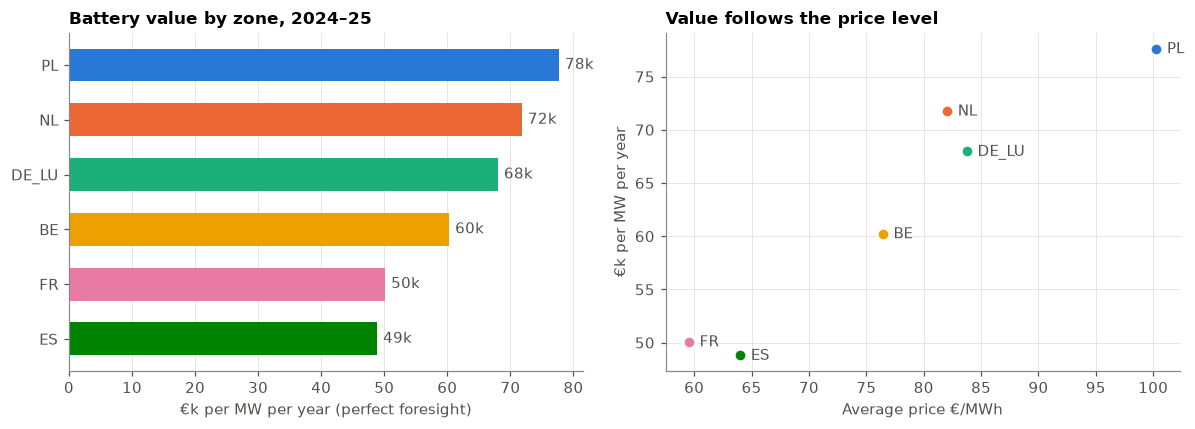

In [5]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 4))
a = atlas.sort("value_per_mw_year")
a1.barh(a["zone"], a["value_per_mw_year"] / 1e3, color=[COLOR[z] for z in a["zone"]], height=0.6)
for z, v in zip(a["zone"], a["value_per_mw_year"]):
    a1.text(v / 1e3 + 1, z, f"{v / 1e3:.0f}k", va="center", color="#52514e")
a1.set_xlabel("€k per MW per year (perfect foresight)")
a1.set_title("Battery value by zone, 2024–25")
a1.grid(axis="y", visible=False)

for z in ZONES:
    r = atlas.filter(pl.col("zone") == z)
    a2.scatter(r["avg_price"], r["value_per_mw_year"] / 1e3, color=COLOR[z], s=70, zorder=3,
               edgecolors="white", linewidths=2)
    a2.annotate(z, (r["avg_price"][0], r["value_per_mw_year"][0] / 1e3),
                xytext=(7, -3), textcoords="offset points", color="#52514e")
a2.set_xlabel("Average price €/MWh")
a2.set_ylabel("€k per MW per year")
a2.set_title("Value follows the price level")
fig.tight_layout()

**What drives the ranking?** Two things stand out in the data:

* **Battery value tracks the daily spread** (correlation 0.90–0.98 between daily value and daily
  max − min, depending on the zone).
* **The spread is a similar multiple of the price level everywhere**, about 1.3–1.4× the average
  price in all six zones.

Together, these mean the ranking is mostly a ranking of **price level**. Poland is first because
it is the most expensive zone. Its coal- and lignite-heavy merit order, with carbon costs on
top, makes the evening peak expensive. It is not first because of renewables: Poland has the
*fewest* negative-price hours of the six. **Negative prices are not what pays a battery; the
evening peak is.**

Spain and France are last for the same reason in reverse. Their average prices are lowest
(nuclear in France, solar and hydro in Spain). Spain has the highest solar share of the six
(about 21% of forecast load), but its prices rarely go deeply negative (the lowest hour was
−€15/MWh), so cheap midday hours still don't create very wide spreads.

The daily shape is the same everywhere: cheapest around 12:00–14:00, most expensive at 19:00
(21:00 in Spain). That is the solar-shift cycle a 2-hour battery is built for.

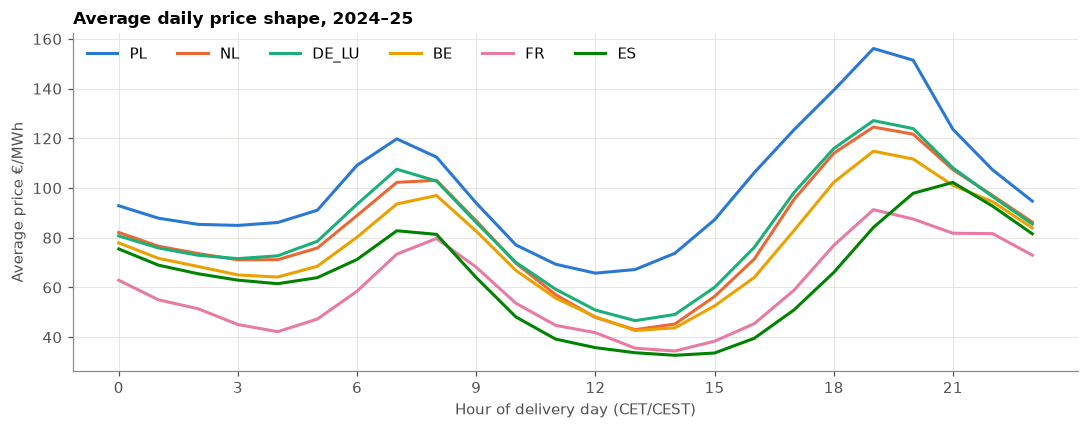

In [6]:
fig, ax = plt.subplots(figsize=(10, 4))
for z in ZONES:
    prof = (
        frames[z]
        .with_columns(pl.col("start_time").dt.convert_time_zone(TZ).dt.hour().alias("h"))
        .group_by("h").agg(pl.col("price").mean()).sort("h")
    )
    ax.plot(prof["h"], prof["price"], color=COLOR[z], label=z)
ax.set_xticks(range(0, 24, 3))
ax.set_xlabel("Hour of delivery day (CET/CEST)")
ax.set_ylabel("Average price €/MWh")
ax.set_title("Average daily price shape, 2024–25")
ax.legend(frameon=False, ncols=6, loc="upper left")
fig.tight_layout()

**2025 was worth more than 2024 in every zone**: spreads widened and negative-price hours
increased everywhere.

In [7]:
by_year = (
    daily.with_columns(pl.col("day").dt.year().alias("year"))
    .group_by("zone", "year")
    .agg(
        (pl.col("bess_value").mean() * 365).alias("eur_per_mw_year"),
        pl.col("spread").mean().alias("avg_spread"),
        (pl.col("neg_hours").sum() / pl.col("hours").sum() * 100).alias("negative_hours_pct"),
    )
    .pivot(on="year", index="zone", values=["eur_per_mw_year", "avg_spread", "negative_hours_pct"])
    .with_columns(
        ((pl.col("eur_per_mw_year_2025") / pl.col("eur_per_mw_year_2024") - 1) * 100)
        .alias("value_change_pct")
    )
    .sort("value_change_pct", descending=True)
)
by_year

zone,eur_per_mw_year_2024,eur_per_mw_year_2025,avg_spread_2024,avg_spread_2025,negative_hours_pct_2024,negative_hours_pct_2025,value_change_pct
str,f64,f64,f64,f64,f64,f64,f64
"""ES""",40011.9,57629.9,71.3,97.2,2.8,6.8,44.0
"""BE""",53489.5,67008.6,91.8,110.7,4.6,5.9,25.3
"""FR""",45411.1,54776.3,76.4,89.7,4.0,5.9,20.6
"""PL""",70487.5,84806.4,120.2,143.8,2.2,3.5,20.3
"""DE_LU""",63513.5,72456.5,106.3,119.6,3.9,5.6,14.1
"""NL""",68164.4,75392.2,113.0,123.2,5.2,6.7,10.6


## 4. Market coupling

Hourly price correlation between zones. DE_LU, NL and BE move almost together (0.91–0.95).
Spain is the least coupled (0.42–0.72), as expected given the limited interconnection across
the Pyrenees, and it is most correlated with France, its only interconnected neighbour in this set.

A caveat on method: correlating price *levels* partly measures shared fuel prices (gas sets the
marginal price in many hours across all zones). A direct measure of coupling would be the share
of hours in which two zones clear at the same price. That is on the next-steps list.

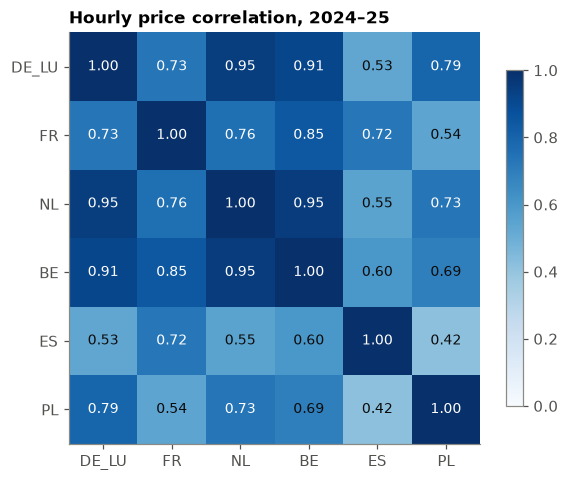

In [8]:
corr = pl.read_csv(REPORTS / "correlation.csv")
z = corr.drop("zone").to_numpy()
fig, ax = plt.subplots(figsize=(5.5, 4.5))
im = ax.imshow(z, cmap="Blues", vmin=0, vmax=1)
ax.set_xticks(range(len(corr)), corr.columns[1:])
ax.set_yticks(range(len(corr)), corr["zone"].to_list())
ax.grid(False)
for i in range(len(z)):
    for j in range(len(z)):
        ax.text(j, i, f"{z[i, j]:.2f}", ha="center", va="center",
                color="white" if z[i, j] > 0.7 else "#0b0b0b", fontsize=9)
ax.set_title("Hourly price correlation, 2024–25")
fig.colorbar(im, shrink=0.8)
fig.tight_layout()

## 5. Forecasting: does a better forecast earn more?

A walk-forward back-test over the **last 90 delivery days** of 2025. For each day, models are
trained only on the previous 180 days (retrained weekly) and forecast all hours of the next
delivery day, using only information available at the 12:00 CET gate closure on D-1:

* price lags of at least 24 hours (D-1 prices are published on D-2), masked when a lag would
  fall inside the delivery day (this happens on the 25-hour autumn DST day);
* the day-ahead load, solar and wind forecasts for day D, which are public before the auction.

Each model's P50 forecast drives the same battery LP, and the schedule is then **settled at
actual prices**. *Revenue capture* is the share of the perfect-foresight revenue it earns.
This is the measure a trader cares about: a forecast with a good MAE that flattens the daily
shape leads to poor trading decisions.

Models: LightGBM and XGBoost (P10/P50/P90 quantile regression), and a **seasonal naive**
baseline (tomorrow = today).

In [9]:
summary = pl.concat([
    pl.read_csv(REPORTS / f"backtest_{z}" / "summary.csv").with_columns(pl.lit(z).alias("zone"))
    for z in ZONES
])
summary.select("zone", "model", "mae", "p10_p90_coverage", "capture_pct", "revenue_eur").sort("zone", "capture_pct", descending=[False, True])

zone,model,mae,p10_p90_coverage,capture_pct,revenue_eur
str,str,f64,f64,f64,f64
"""BE""","""XGBoost""",11.9,0.5,81.7,6938.9
"""BE""","""LightGBM""",11.8,0.5,81.3,6897.6
"""BE""","""Seasonal naive""",19.9,0.0,62.2,5282.1
"""DE_LU""","""LightGBM""",9.9,0.5,92.3,10620.3
"""DE_LU""","""XGBoost""",9.9,0.5,92.1,10596.9
"""DE_LU""","""Seasonal naive""",25.6,0.0,76.6,8814.1
"""ES""","""XGBoost""",10.7,0.4,89.8,10500.8
"""ES""","""LightGBM""",10.7,0.5,89.7,10489.7
"""ES""","""Seasonal naive""",19.9,0.0,75.9,8875.1


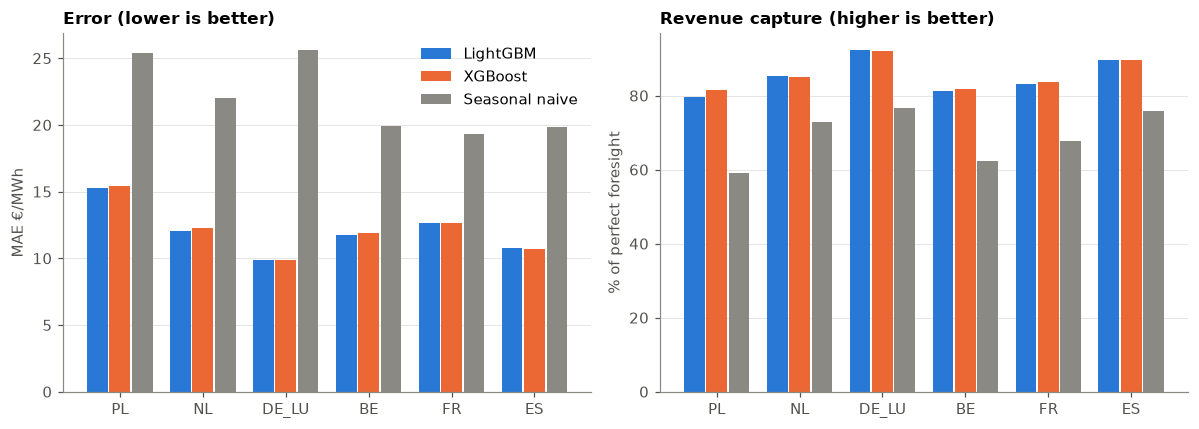

In [10]:
MODEL_COLOR = {"LightGBM": "#2a78d6", "XGBoost": "#eb6834", "Seasonal naive": "#8a8984"}
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 4))
x = np.arange(len(ZONES))
for k, (m, c) in enumerate(MODEL_COLOR.items()):
    s = summary.filter(pl.col("model") == m)
    s = dict(zip(s["zone"], zip(s["mae"], s["capture_pct"])))
    a1.bar(x + (k - 1) * 0.27, [s[z][0] for z in ZONES], 0.25, color=c, label=m)
    a2.bar(x + (k - 1) * 0.27, [s[z][1] for z in ZONES], 0.25, color=c, label=m)
for ax, title, unit in [(a1, "Error (lower is better)", "MAE €/MWh"),
                        (a2, "Revenue capture (higher is better)", "% of perfect foresight")]:
    ax.set_xticks(x, ZONES)
    ax.set_ylabel(unit)
    ax.set_title(title)
    ax.grid(axis="x", visible=False)
a1.legend(frameon=False)
fig.tight_layout()

**What the back-test shows** (1 October to 31 December 2025):

* **Fundamentals pay.** LightGBM and XGBoost roughly halve the error of the seasonal naive
  baseline in every zone, and capture **80–92%** of perfect-foresight revenue against
  **59–77%** for the baseline. In DE_LU that is about €1,800/MW more over the 90 days.
* **Revenue capture separates zones that MAE does not.** DE_LU and ES reach about 90% capture;
  PL, BE and FR stay near 80%, even though their MAE is similar. Capture depends on getting the
  *timing* of the cheap and expensive hours right, not on the average error.
* **LightGBM and XGBoost are within one point of each other.** Without a significance test
  (Diebold–Mariano), neither can be called better.
* **The uncertainty bands are too narrow.** A P10–P90 band should contain about 80% of actual
  prices; here it contains only 40–60%, so the models are overconfident. Likely causes are
  overfitting (600 trees on about 4,300 training rows) and a seasonal shift (training mostly on
  summer and autumn, testing on winter). The standard fix is conformal calibration of the
  quantiles. The seasonal naive band is 0% by construction (P10 = P50 = P90).

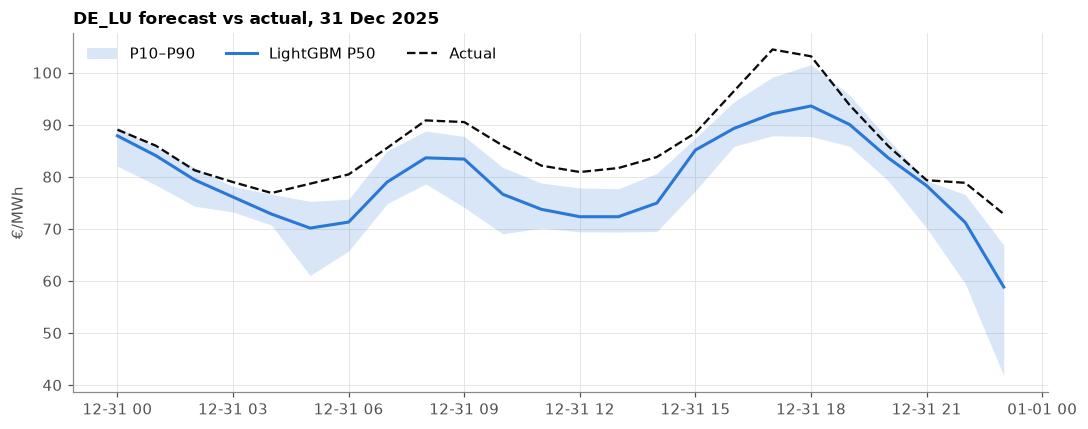

In [11]:
pred = pl.read_parquet(REPORTS / "backtest_DE_LU" / "predictions.parquet").with_columns(
    pl.col("start_time").dt.convert_time_zone(TZ).alias("t")
)
best = summary.filter(pl.col("zone") == "DE_LU").sort("capture_pct", descending=True)["model"][0]
p = pred.filter(pl.col("model") == best)
last_day = p["t"].dt.date().max()
d = p.filter(pl.col("t").dt.date() == last_day)

fig, ax = plt.subplots(figsize=(10, 4))
ax.fill_between(d["t"], d["p10"], d["p90"], color="#2a78d6", alpha=0.18, linewidth=0, label="P10–P90")
ax.plot(d["t"], d["p50"], color="#2a78d6", label=f"{best} P50")
ax.plot(d["t"], d["actual"], color="#0b0b0b", linewidth=1.5, linestyle="--", label="Actual")
ax.set_ylabel("€/MWh")
ax.set_title(f"DE_LU forecast vs actual, {last_day:%d %b %Y}")
ax.legend(frameon=False, ncols=3, loc="upper left")
fig.tight_layout()

## 6. Explaining a forecast

A tree model is not a black box if you can show what drove each prediction.
`LightGBMQuantile.contributions` returns **SHAP values**, computed natively by LightGBM
(TreeSHAP): for one hour, how many €/MWh each feature pushed the P50 forecast above or below
the model's average. Contributions plus the base value add up exactly to the forecast, and a
unit test checks this.

Below: a P50 model trained on the 180 days before December 2025, explaining the hour in
December where its forecast was furthest from average. Extreme hours are where an explanation
is most useful.

base value (average forecast) €83.7  +  contributions €+199.3  =  forecast €283.1/MWh
{'load_fc': 70159, 'solar_fc': 0, 'wind_fc': 4179, 'residual_load_fc': 65979}


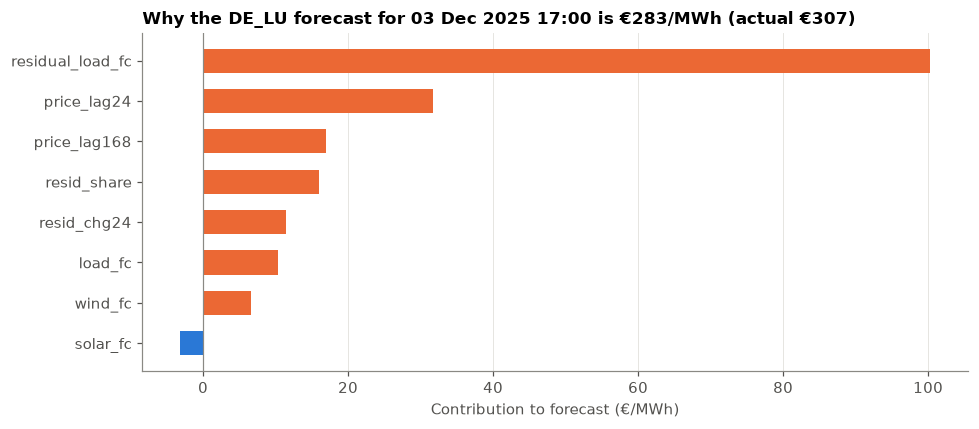

In [12]:
df = frames["DE_LU"]
feats = eu_features(df).with_columns(
    pl.col("start_time").dt.convert_time_zone(TZ).dt.date().alias("day"),
    pl.col("start_time").dt.convert_time_zone(TZ).dt.hour().alias("local_hour"),
)
cols = [c for c in eu_feature_columns(feats) if c != "local_hour"]
target = date(2025, 12, 1)
train = feats.filter(pl.col("day").is_between(target - timedelta(days=180), target, closed="left"))
model = LightGBMQuantile(ModelConfig(quantiles=[0.5]))
model.fit(train.select(cols).to_numpy().astype(np.float64), train["price"].to_numpy())

dec = feats.filter(pl.col("day") >= target)
contrib = model.contributions(dec.select(cols).to_numpy().astype(np.float64))
k = int(np.argmax(np.abs(contrib[:, :-1].sum(axis=1))))  # hour furthest from the average
base, parts = contrib[k, -1], contrib[k, :-1]
row = dec.row(k, named=True)
top = np.argsort(np.abs(parts))[::-1][:8][::-1]

fig, ax = plt.subplots(figsize=(9, 4))
ax.barh([cols[i] for i in top], parts[top], height=0.6,
        color=["#eb6834" if parts[i] > 0 else "#2a78d6" for i in top])
ax.axvline(0, color="#8a8984", linewidth=0.8)
ax.set_xlabel("Contribution to forecast (€/MWh)")
ax.set_title(f"Why the DE_LU forecast for {row['day']:%d %b %Y} {row['local_hour']:02d}:00 is "
             f"€{base + parts.sum():.0f}/MWh (actual €{row['price']:.0f})")
ax.grid(axis="y", visible=False)
fig.tight_layout()
print(f"base value (average forecast) €{base:.1f}  +  contributions €{parts.sum():+.1f}"
      f"  =  forecast €{base + parts.sum():.1f}/MWh")
print({c: round(row[c]) for c in ["load_fc", "solar_fc", "wind_fc", "residual_load_fc"]})

Orange bars pushed the price up, blue bars pushed it down. The hour picked is
**3 December 2025, 17:00**, a *Dunkelflaute* evening: 70 GW of forecast load, 4 GW of wind and
no solar. Starting from an average forecast of about €84/MWh, the high residual load alone adds
about €100, and a high price the day before adds another €32. The model forecast €283; the
actual price was €307. The explanation matches how a trader would read that evening.

Across all hours of December, the average size of each feature's contribution gives a global
ranking of what the model relies on. Residual load is far ahead of everything else, including
yesterday's price:

In [13]:
imp = pl.DataFrame({"feature": cols, "mean_abs_eur": np.abs(contrib[:, :-1]).mean(axis=0)}).sort("mean_abs_eur", descending=True)
imp.head(10)

feature,mean_abs_eur
str,f64
"""residual_load_fc""",21.4
"""price_lag24""",4.5
"""resid_share""",3.5
"""price_lag168""",3.3
"""resid_chg24""",3.1
"""load_fc""",2.0
"""hour""",1.1
"""solar_fc""",0.8
"""price_rstd168""",0.8


## 7. Limits and next steps

**Limits of these results**

* **Hourly prices.** SDAC moved to 15-minute periods on 1 October 2025. The pipeline averages
  them to hourly, which smooths out some of the spread, so the late-2025 values understate what
  a battery could earn on 15-minute prices.
* **Day-ahead only.** Intraday, balancing and ancillary services (often the larger revenue
  streams) are not included.
* **Perfect foresight** in the atlas is an upper bound, not an expected return.
* **No fuel prices.** TTF gas and EUA carbon prices drive the price level but are not features yet.

**Next steps**

1. Benchmark against **LEAR** (Lago et al., 2021), the standard reference model for day-ahead
   price forecasting, with a Diebold–Mariano test for significance.
2. Add TTF gas and EUA carbon prices as fundamentals.
3. Run the battery LP on native 15-minute prices.
4. Measure coupling as price-convergence frequency rather than correlation.